In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("netflix_titles.csv")
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


1. Which countries produce the most Netflix content?



In [ ]:
df['country'].dropna().str.split(', ').explode().value_counts().head()

,count
country,
United States,3689
India,1046
United Kingdom,804
Canada,445
France,393


2. What are the top 10 most common genres on Netflix?

In [ ]:
df['listed_in'].str.split(', ').explode().value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


3. Which genre has the highest number of movies?

In [ ]:
df[df['type']=='Movie']['listed_in'].str.split(', ').explode().value_counts().head()

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
Documentaries,869
Action & Adventure,859


4. Which genre is most common for TV shows?

In [ ]:
df[df['type']=='TV Show']['listed_in'].str.split(', ').explode().value_counts().head()

,count
listed_in,
International TV Shows,1351
TV Dramas,763
TV Comedies,581
Crime TV Shows,470
Kids' TV,451


5. What is the average duration of movies on Netflix?

In [ ]:
df[df['type'] == 'Movie']['duration'].str.replace(' min','').astype(float).mean()


np.float64(99.57718668407311)

# 🔹 Time & Trend Analysis


6. How has Netflix content grown over the years?

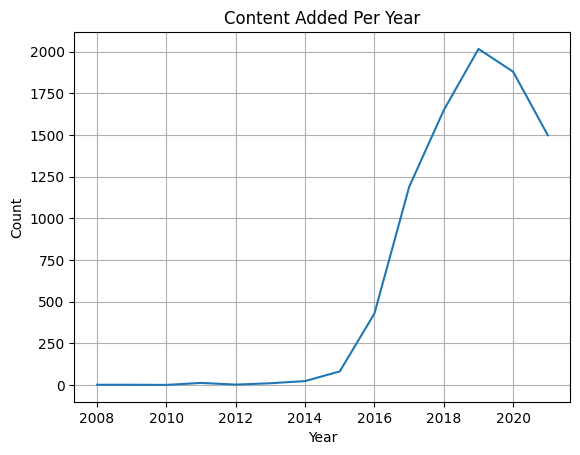

In [ ]:
pd.to_datetime(df['date_added'], format='mixed').dt.year.value_counts().sort_index().plot()
plt.title("Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.show()

7. In which month does Netflix add the most content?

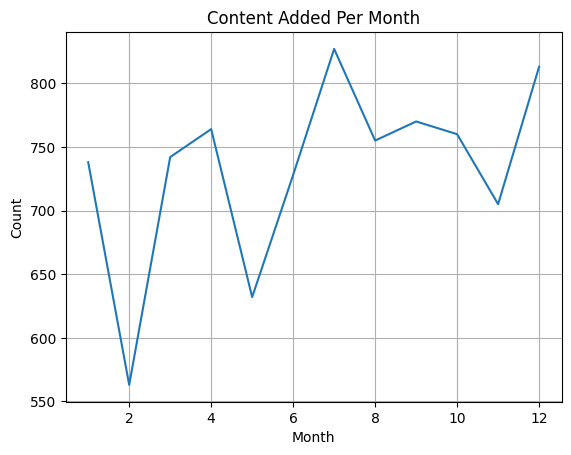

In [ ]:
pd.to_datetime(df['date_added'], format='mixed').dt.month.value_counts().sort_index().plot()
plt.title("Content Added Per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.grid(True)
plt.show()


8. Has the number of TV shows increased faster than movies?

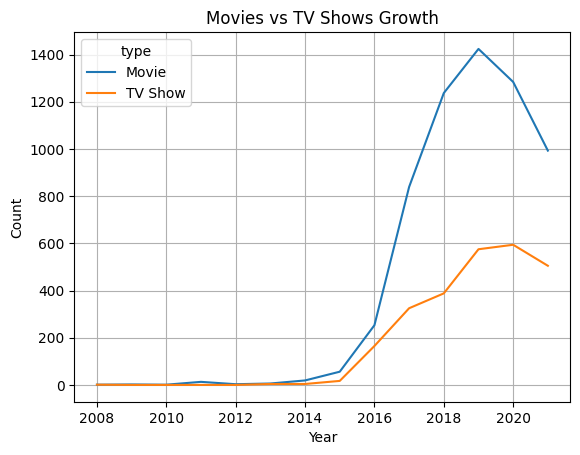

In [ ]:
df['year_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year
df.groupby(['year_added', 'type']).size().unstack(fill_value=0).plot()
plt.title("Movies vs TV Shows Growth")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.show()

9. What is the trend of content addition after 2015?

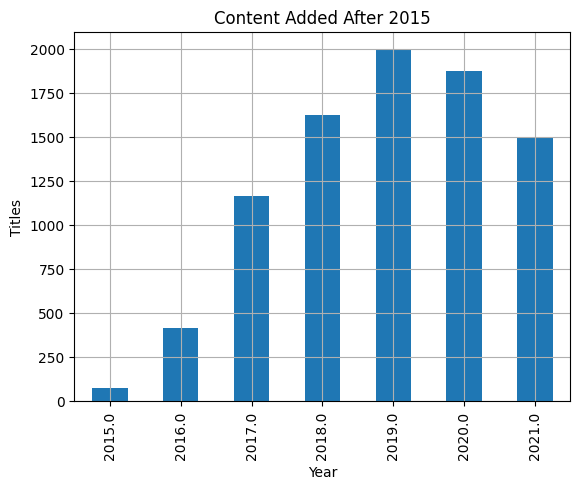

In [ ]:
df[df['year_added'] >= 2015]['year_added'].value_counts().sort_index().plot(kind='bar')
plt.title("Content Added After 2015")
plt.xlabel("Year")
plt.ylabel("Titles")
plt.grid(True)
plt.show()

# 🔹 Country & Language Insights


10. Which country has the highest number of TV shows?

In [ ]:
df[df['type'] == 'TV Show']['country'].dropna().str.split(', ').explode().value_counts().head(1)

,count
country,
United States,938


11. Compare Indian content vs US content on Netflix.

In [ ]:
pd.concat({'India': df[df['country'].str.contains('India', na=False)]['listed_in'].str.split(', ').explode().value_counts().head(5),
           'United States': df[df['country'].str.contains('United States', na=False)]['listed_in'].str.split(', ').explode().value_counts().head(5)}, axis=1)


,India,United States
listed_in,,
International Movies,864.0,NaN
Dramas,662.0,835.0
Comedies,323.0,680.0
Independent Movies,167.0,NaN
Action & Adventure,137.0,404.0
Documentaries,NaN,512.0
Children & Family Movies,NaN,390.0


12. Which countries focus more on movies than TV shows?

In [ ]:
df.dropna(subset=['country']).assign(country=df['country'].str.split(', ')).explode('country').groupby(['country','type']).size().unstack(fill_value=0).query('Movie > `TV Show`').sort_values('Movie', ascending=False).head()


type,Movie,TV Show
country,,
United States,2751,938
India,962,84
United Kingdom,532,272
Canada,319,126
France,303,90


13. What type of content is most popular in India?

In [ ]:
df[df['country'].str.contains('India', na=False)]['listed_in'].str.split(', ').explode().value_counts().head()

,count
listed_in,
International Movies,864
Dramas,662
Comedies,323
Independent Movies,167
Action & Adventure,137
